In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/content/application_train.csv")
assert df.shape == (307511, 122), f"Wrong or truncated file: {df.shape}"
print("Raw shape:", df.shape)

y = df["TARGET"]
X = df.drop(columns=["TARGET", "SK_ID_CURR"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("Train ratio:\n", y_train.value_counts(normalize=True))
print("Test ratio:\n", y_test.value_counts(normalize=True))

Raw shape: (307511, 122)
X_train: (246008, 120)
X_test: (61503, 120)
Train ratio:
 TARGET
0    0.919271
1    0.080729
Name: proportion, dtype: float64
Test ratio:
 TARGET
0    0.919272
1    0.080728
Name: proportion, dtype: float64


In [54]:
cols_missing_50 = [
    'OWN_CAR_AGE', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BUILD_AVG',
    'COMMONAREA_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMIN_AVG',
    'LANDAREA_AVG', 'LIVINGAPARTMENTS_AVG', 'LIVINGAREA_AVG',
    'NONLIVINGAPARTMENTS_AVG', 'NONLIVINGAREA_AVG',
    'APARTMENTS_MODE', 'BASEMENTAREA_MODE', 'YEARS_BUILD_MODE',
    'COMMONAREA_MODE', 'ELEVATORS_MODE', 'ENTRANCES_MODE', 'FLOORSMIN_MODE',
    'LANDAREA_MODE', 'LIVINGAPARTMENTS_MODE', 'LIVINGAREA_MODE',
    'NONLIVINGAPARTMENTS_MODE', 'NONLIVINGAREA_MODE',
    'APARTMENTS_MEDI', 'BASEMENTAREA_MEDI', 'YEARS_BUILD_MEDI',
    'COMMONAREA_MEDI', 'ELEVATORS_MEDI', 'ENTRANCES_MEDI', 'FLOORSMIN_MEDI',
    'LANDAREA_MEDI', 'LIVINGAPARTMENTS_MEDI', 'LIVINGAREA_MEDI',
    'NONLIVINGAPARTMENTS_MEDI', 'NONLIVINGAREA_MEDI',
    'FONDKAPREMONT_MODE', 'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE',
]

group1_drop = [
    'FLOORSMAX_AVG', 'FLOORSMAX_MODE', 'FLOORSMAX_MEDI',
    'YEARS_BEGINEXPLUATATION_AVG', 'YEARS_BEGINEXPLUATATION_MODE',
    'YEARS_BEGINEXPLUATATION_MEDI',
    'TOTALAREA_MODE', 'EMERGENCYSTATE_MODE',
]

drop_cols = cols_missing_50 + group1_drop
print("Total columns to drop:", len(drop_cols))   # 48

X_train = X_train.drop(columns=drop_cols)
X_test = X_test.drop(columns=drop_cols)

print("X_train:", X_train.shape)   # (246008, 72)
print("X_test:", X_test.shape)     # (61503, 72)

Total columns to drop: 48
X_train: (246008, 72)
X_test: (61503, 72)


In [55]:
# LEARN medians from TRAIN ONLY
median_cols = [
    "EXT_SOURCE_1", "EXT_SOURCE_2", "EXT_SOURCE_3",
    "OBS_60_CNT_SOCIAL_CIRCLE", "DEF_30_CNT_SOCIAL_CIRCLE",
    "DEF_60_CNT_SOCIAL_CIRCLE", "OBS_30_CNT_SOCIAL_CIRCLE",
    "AMT_GOODS_PRICE", "AMT_ANNUITY", "CNT_FAM_MEMBERS",
    "DAYS_LAST_PHONE_CHANGE",
]
medians = X_train[median_cols].median().to_dict()
print(medians)

# APPLY the same medians to BOTH sets
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

# Fixed rules (not learned, so no leakage possible)
unknown_cols = ["OCCUPATION_TYPE", "NAME_TYPE_SUITE"]
bureau_cols = [
    "AMT_REQ_CREDIT_BUREAU_YEAR", "AMT_REQ_CREDIT_BUREAU_WEEK",
    "AMT_REQ_CREDIT_BUREAU_DAY", "AMT_REQ_CREDIT_BUREAU_QRT",
    "AMT_REQ_CREDIT_BUREAU_MON", "AMT_REQ_CREDIT_BUREAU_HOUR",
]
for df_ in (X_train, X_test):
    df_[unknown_cols] = df_[unknown_cols].fillna("Unknown")
    df_[bureau_cols] = df_[bureau_cols].fillna(0)

print("Nulls in train:", X_train.isnull().sum().sum())   # 0
print("Nulls in test:", X_test.isnull().sum().sum())     # 0
print(X_train.shape, X_test.shape)

{'EXT_SOURCE_1': 0.5054455334342673, 'EXT_SOURCE_2': 0.5659130796679341, 'EXT_SOURCE_3': 0.5352762504724826, 'OBS_60_CNT_SOCIAL_CIRCLE': 0.0, 'DEF_30_CNT_SOCIAL_CIRCLE': 0.0, 'DEF_60_CNT_SOCIAL_CIRCLE': 0.0, 'OBS_30_CNT_SOCIAL_CIRCLE': 0.0, 'AMT_GOODS_PRICE': 450000.0, 'AMT_ANNUITY': 24903.0, 'CNT_FAM_MEMBERS': 2.0, 'DAYS_LAST_PHONE_CHANGE': -757.0}
Nulls in train: 0
Nulls in test: 0
(246008, 72) (61503, 72)


In [56]:
# Frequency maps learned from TRAIN ONLY
freq_cols = ["OCCUPATION_TYPE", "ORGANIZATION_TYPE"]
freq_maps = {
    col: X_train[col].value_counts(normalize=True).to_dict()
    for col in freq_cols
}

for col in freq_cols:
    X_train[col] = X_train[col].map(freq_maps[col])
    unseen = X_test[col].map(freq_maps[col]).isnull().sum()
    print(col, "- unseen categories in test:", unseen)
    X_test[col] = X_test[col].map(freq_maps[col]).fillna(0)   # 0 = never seen in train

# One-hot: the column list is decided by TRAIN
onehot_cols = [
    "NAME_CONTRACT_TYPE", "CODE_GENDER", "FLAG_OWN_CAR", "FLAG_OWN_REALTY",
    "NAME_TYPE_SUITE", "NAME_INCOME_TYPE", "NAME_EDUCATION_TYPE",
    "NAME_FAMILY_STATUS", "NAME_HOUSING_TYPE", "WEEKDAY_APPR_PROCESS_START",
]

X_train = pd.get_dummies(X_train, columns=onehot_cols, drop_first=True, dtype=int)
train_columns = X_train.columns.tolist()

# drop_first=False on test on purpose: if a test set (or a single API row) were
# missing the train baseline category, drop_first=True would drop a DIFFERENT column.
# reindex() below removes the baseline columns and any unseen categories.
X_test = pd.get_dummies(X_test, columns=onehot_cols, drop_first=False, dtype=int)
X_test = X_test.reindex(columns=train_columns, fill_value=0)

print("X_train:", X_train.shape)   # (246008, 101)
print("X_test:", X_test.shape)     # (61503, 101)
print("Object columns left:", X_train.select_dtypes(include="object").columns.tolist())
print("Nulls:", X_train.isnull().sum().sum(), X_test.isnull().sum().sum())
print("Columns match:", list(X_test.columns) == train_columns)

OCCUPATION_TYPE - unseen categories in test: 0
ORGANIZATION_TYPE - unseen categories in test: 0
X_train: (246008, 101)
X_test: (61503, 101)
Object columns left: []
Nulls: 0 0
Columns match: True


In [57]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
log_reg.fit(X_train_scaled, y_train)

proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]
pred_lr = log_reg.predict(X_test_scaled)

print("LR ROC-AUC:", roc_auc_score(y_test, proba_lr))
print(classification_report(y_test, pred_lr))
print(confusion_matrix(y_test, pred_lr))

LR ROC-AUC: 0.7475595324546579
              precision    recall  f1-score   support

           0       0.96      0.69      0.80     56538
           1       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503

[[39007 17531]
 [ 1618  3347]]


In [58]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_fixed = XGBClassifier(
    max_depth=5,
    learning_rate=0.05,
    n_estimators=300,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    eval_metric="auc",
    n_jobs=-1,
)
xgb_fixed.fit(X_train, y_train)

proba_xgb = xgb_fixed.predict_proba(X_test)[:, 1]
pred_xgb = xgb_fixed.predict(X_test)

print("XGB ROC-AUC:", roc_auc_score(y_test, proba_xgb))
print(classification_report(y_test, pred_xgb))
print(confusion_matrix(y_test, pred_xgb))

XGB ROC-AUC: 0.7610597059604005
              precision    recall  f1-score   support

           0       0.96      0.71      0.82     56538
           1       0.17      0.67      0.27      4965

    accuracy                           0.71     61503
   macro avg       0.57      0.69      0.55     61503
weighted avg       0.90      0.71      0.78     61503

[[40367 16171]
 [ 1633  3332]]


In [59]:
import os, joblib, sklearn, xgboost, pandas

os.makedirs("artifacts", exist_ok=True)

joblib.dump(xgb_fixed, "artifacts/xgb_model.pkl")
joblib.dump(medians, "artifacts/medians.pkl")
joblib.dump(freq_maps, "artifacts/freq_maps.pkl")
joblib.dump(train_columns, "artifacts/train_columns.pkl")

config = {
    "drop_cols": drop_cols,
    "median_cols": median_cols,
    "unknown_cols": unknown_cols,
    "bureau_cols": bureau_cols,
    "freq_cols": freq_cols,
    "onehot_cols": onehot_cols,
}
joblib.dump(config, "artifacts/config.pkl")

print("pandas:", pandas.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)
print("numpy:", __import__("numpy").__version__)

loaded = joblib.load("artifacts/xgb_model.pkl")
same = (loaded.predict_proba(X_test)[:, 1] == proba_xgb).all()
print("Reloaded model matches:", same)
print(os.listdir("artifacts"))

pandas: 2.2.3
scikit-learn: 1.6.1
xgboost: 3.4.1
numpy: 2.1.3
Reloaded model matches: True
['train_columns.pkl', 'xgb_model.pkl', 'config.pkl', 'medians.pkl', 'freq_maps.pkl']


In [60]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb_fixed, X_train, y_train, cv=cv, scoring="roc_auc", n_jobs=-1)

print("Fold scores:", cv_scores)
print("Mean:", cv_scores.mean())
print("Std:", cv_scores.std())

Fold scores: [0.75602573 0.7555531  0.75762459 0.7573355  0.75398144]
Mean: 0.7561040715818638
Std: 0.0013148117204573465


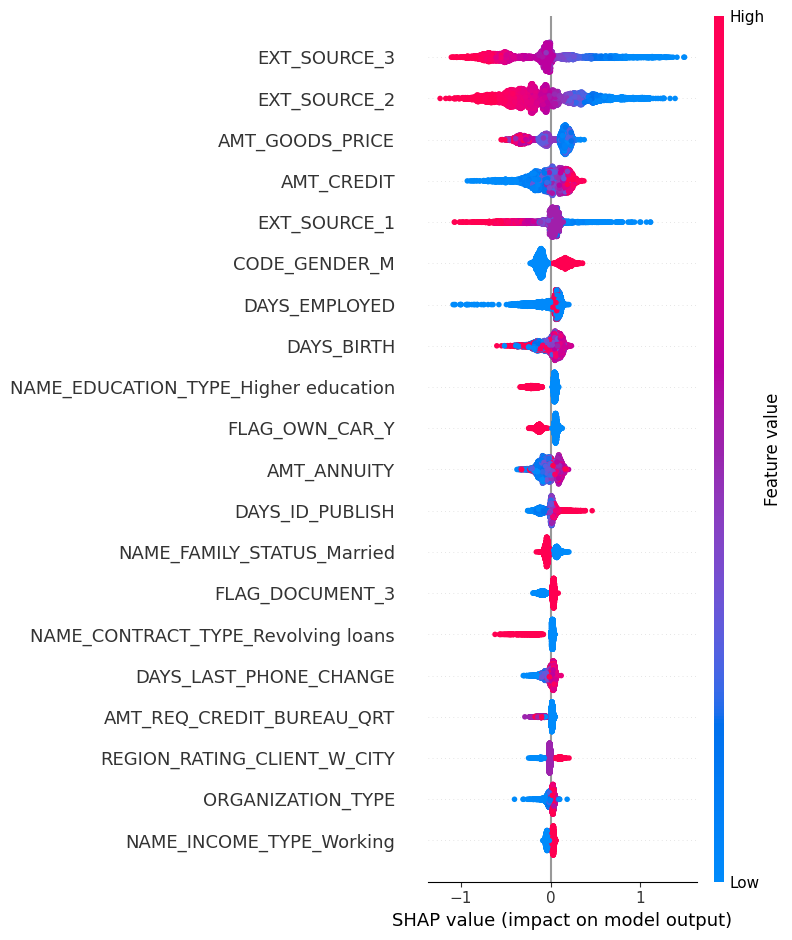

EXT_SOURCE_3                            0.377744
EXT_SOURCE_2                            0.356067
AMT_GOODS_PRICE                         0.186043
AMT_CREDIT                              0.158607
EXT_SOURCE_1                            0.154658
CODE_GENDER_M                           0.132486
DAYS_EMPLOYED                           0.109346
DAYS_BIRTH                              0.097223
NAME_EDUCATION_TYPE_Higher education    0.086876
FLAG_OWN_CAR_Y                          0.085411
dtype: float32


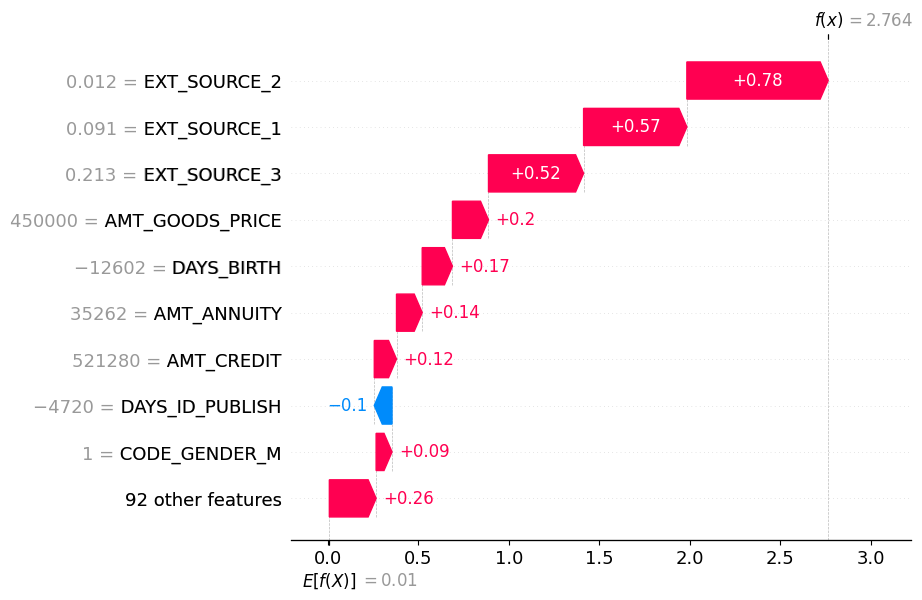

In [61]:
!pip install shap --quiet

import shap
import numpy as np
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(xgb_fixed)

X_sample = X_test.sample(5000, random_state=42)
shap_values = explainer(X_sample)

# Global summary plot
plt.figure()
shap.summary_plot(shap_values, X_sample, show=False)
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=150, bbox_inches="tight")
plt.show()

# Exact top-10 ranking by mean |SHAP|
importance = pd.Series(
    np.abs(shap_values.values).mean(axis=0), index=X_sample.columns
).sort_values(ascending=False)
print(importance.head(10))

# Local: highest-risk applicant in the sample
p = xgb_fixed.predict_proba(X_sample)[:, 1]
i = int(np.argmax(p))
plt.figure()
shap.plots.waterfall(shap_values[i], show=False)
plt.savefig("shap_local_example.png", dpi=150, bbox_inches="tight")
plt.show()

In [62]:
print(X_train[["AMT_CREDIT", "AMT_GOODS_PRICE"]].corr())

                 AMT_CREDIT  AMT_GOODS_PRICE
AMT_CREDIT         1.000000         0.986757
AMT_GOODS_PRICE    0.986757         1.000000


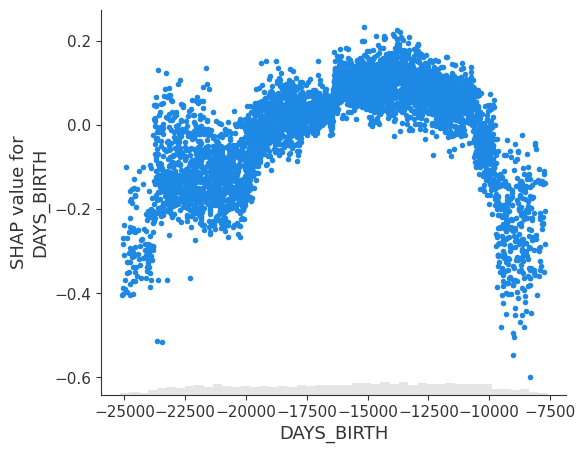

In [63]:
shap.plots.scatter(shap_values[:, "DAYS_BIRTH"])

In [64]:
age_years = -X_sample["DAYS_BIRTH"] / 365
age_group = pd.qcut(age_years, 4)
shap_birth = pd.Series(shap_values[:, "DAYS_BIRTH"].values, index=X_sample.index)
print(shap_birth.groupby(age_group, observed=True).mean())

DAYS_BIRTH
(21.089, 33.865]   -0.041939
(33.865, 42.734]    0.102045
(42.734, 53.827]    0.037285
(53.827, 68.721]   -0.124873
dtype: float32
